# Notebook 07 — Missingness & Sampling Bias

> **Supplementary** — extends the robustness validation in NB06

**Scope:** The main PCA analysis (NB04) uses ~126k bilateral frames where all 8 markers were successfully labelled, split into unilateral frames. Some configurations are over-represented in the complete dataset, in particular gliding poses. These have outstretched wings and tail and are easier for the cameras to pick up feather markers compared with folded configurations. Gliding frames were more likely to contain all eight markers visible and are the easiest to label.

The motion-capture system also recorded many more frames where one or more markers were missing, either occluded by the bird’s body, outside the capture volume, or mislabelled by the reconstruction pipeline. A larger dataset of ~559k bilateral frames includes these partial observations.

This notebook asks:
1. **Sampling bias** — does the complete dataset oversample certain postures, and does that affect the PCA results?
2. **Missingness patterns** — which markers drop out, when, and is there evidence of mislabelling?

Cross-reference NB06 (Robustness Validation) for the quantitative tests showing these limitations affect sampling density, not morphospace structure.

## Contents
1. [Dataset Overview](#dataset-overview)
2. [Does Sampling Bias Affect the PCA?](#does-sampling-bias-affect-the-pca)
3. [Density Comparison: Complete vs Partial Frames](#density-comparison-complete-vs-partial-frames)
4. [Occlusion Robustness](#occlusion-robustness)
5. [Missingness Patterns](#missingness-patterns)
6. [Summary & Limitations](#summary--limitations)

In [1]:
# --- Setup ---
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format='retina'

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.rcParams['font.family'] = 'Andale Mono'
np.set_printoptions(suppress=True, precision=4)

import itertools

from kinematic_morphospace import (
    filter_by, to_unilateral, run_PCA, principal_cosines,
    print_occlusion_pca, print_projection_validation,
    print_complete_markers_summary, print_partial_markers_summary,
    print_dataset_split, print_density_shift_table,
    print_marker_dropout_rates, print_anatomical_violations, print_violation_breakdown,
    print_phase_pca_summary,
)
from kinematic_morphospace.pca_core import get_PCA_input
from kinematic_morphospace.null_testing import prepare_missing_marker_dataset
from kinematic_morphospace.plotting import save_figure

MARKER_NAMES = ['wingtip', 'primary', 'secondary', 'tailtip']
FIGURE_DIR = Path('../../figures/supplementary')


## Data loading

- **Complete markers** (`complete_markers`) — 126k unilateral frames with all 4 markers labelled per side; the main analysis dataset from NB02
- **Partial markers** (`partial_unilateral`) — 559k unilateral frames including those with missing markers; for occlusion and bias tests


In [2]:
# --- Complete markers (all labelled, from NB02) ---
complete_markers = np.load("../../data/unilateral/data.npy")
frame_info = pd.read_csv("../../data/unilateral/frame_info.csv")
n_complete = complete_markers.shape[0]
print_complete_markers_summary(n_complete, complete_markers)

# --- Partial markers (including frames with missing markers) ---
partial_unilateral, partial_bilateral, partial_info = prepare_missing_marker_dataset(
    "../../data/raw/labelled_markers_with_missing.npz",
    "../../src/kinematic_morphospace/TotalWingspans.yml",
)
# (partial summary printed after complete_unilateral is defined below)

# --- Complete straight-flight subset for occlusion comparisons ---
complete_info = pd.read_csv("../../data/bilateral/frame_info.csv")
bilateral_straight = (complete_info["Obstacle"] == 0).values
straight_unilateral = np.concatenate([bilateral_straight, bilateral_straight])
complete_unilateral = complete_markers[straight_unilateral]
print_partial_markers_summary(partial_bilateral, partial_unilateral, complete_unilateral)
# --- Straight-flight subset of partial dataset ---
hawk_names = {1: "Drogon", 2: "Rhaegal", 3: "Ruby", 4: "Toothless", 5: "Charmander"}
straight_missing = (partial_info["Obstacle"] == 0).values
missing_straight = partial_bilateral[straight_missing]


Complete markers: 289,528 unilateral frames
  (144,764 bilateral x 2 sides)
  Markers per frame: 4
  Coordinates: 3 (x, y, z)

Partial markers: 559,421 bilateral frames
  Straight-flight unilateral: 936,806
  Complete straight-flight unilateral: 252,630


In [3]:
# --- Separate complete vs genuinely partial frames in the broader dataset ---
any_nan = np.any(np.isnan(partial_unilateral), axis=(1, 2))
complete_data = partial_unilateral[~any_nan]
partial_data = partial_unilateral[any_nan]

print_dataset_split(complete_data, partial_data, partial_unilateral)

Within the broader dataset:
  Complete frames (all 4 markers): 383,910
  Partial frames (≥1 marker missing): 552,896
  Partial fraction: 59.0%


## Does Sampling Bias Affect the PCA?

The complete dataset contains only frames where all markers were visible. If certain postures systematically lose markers, the complete dataset oversamples the remaining postures. Does this bias the PCA results?

We test this directly using the `flightPhase` metadata, which segments each flight into phases with different wing kinematics.

| Phase | Description | Distance from perch (12 m flights) |
|-------|-------------|---------------------------------------|
| 1 | Takeoff — large flapping | 11.5-10.0 m |
| 2 | Cruise — smaller flapping | 10.0-7.0 m |
| 3 | Transition — flapping to gliding | 7.0-5.5 m |
| 4 | Glide + pitch-up landing | 5.5-0.3 m |

### Independent PCA analysis

We first run PCA separately on each phase and compare the variance concentration (CEV₄) against the full dataset. Each phase is free to vary in its own space, and the modes are not directly comparable across phases. If the complete dataset's 96.3% in 4 modes were inflated by oversampling one phase, we would expect that phase to have a much higher CEV₄ than the others.

### Shared PCA basis

We also run PCA on the complete dataset and project each phase's frames into the full PCA basis to see how their variance concentration compares. The modes from the complete dataset are then comparable across the phases, and we can check if the same modes are driving variance in each phase or if they differ.

If the variance concentration (96.3% in 4 modes) were inflated by oversampling one phase, CEV₄ should vary across phases. If the same modes are driving variance in each phase, the shared PCA basis should show a similar pattern of CEV₄ across phases as the independent PCAs. If different modes are important in different phases, the shared PCA basis may show a different pattern of CEV₄ across phases than the independent PCAs.

In [4]:
# --- PCA per flight phase ---
# Get flight phase for unilateral frames
phase_bilateral = partial_info[straight_missing]["flightPhase"].astype(int).values
phase_unilateral = np.concatenate([phase_bilateral, phase_bilateral])
complete_phase = phase_unilateral[~any_nan]

phase_labels = {1: "Take-off", 2: "Flapping",
                3: "Transition", 4: "Glide + landing"}

# --- A) Independent PCA per phase ---
independent = {}
for phase in sorted(np.unique(complete_phase)):
    mask = complete_phase == phase
    _, _, pca_phase = run_PCA(complete_data[mask])
    independent[phase] = {
        "n": mask.sum(),
        "cev": np.cumsum(pca_phase.explained_variance_ratio_[:4]),
    }
_, _, pca_all = run_PCA(complete_data)
independent["all"] = {
    "n": complete_data.shape[0],
    "cev": np.cumsum(pca_all.explained_variance_ratio_[:4]),
}

# --- B) Shared PCA axes: project each phase into full-dataset modes ---
_, all_scores, _ = run_PCA(complete_data)
shared_cev, shared_var = {}, {}
for phase in sorted(np.unique(complete_phase)):
    mask = complete_phase == phase
    v = np.var(all_scores[mask], axis=0)
    shared_cev[phase] = {"n": mask.sum(), "cev": np.cumsum(v[:4]) / v.sum()}
    shared_var[phase] = {"n": mask.sum(), "var": v}
v_all = np.var(all_scores, axis=0)
shared_cev["all"] = {"n": complete_data.shape[0], "cev": np.cumsum(v_all[:4]) / v_all.sum()}
shared_var["all"] = {"n": complete_data.shape[0], "var": v_all}

# --- Print summary ---
print_phase_pca_summary({
    "phase_labels": phase_labels,
    "independent": independent,
    "shared_cev": shared_cev,
    "shared_var": shared_var,
})

NameError: name 'straight_missing' is not defined

**Result.** Both approaches agree: CEV₄ is highest in the flapping phases (1–2: ~97%) and lowest in the glide + landing phase (4: ~91%). The combined 96.3% is pulled down by phase 4, not inflated by it.

The absolute variance table shows in the shared modes, Modes 1–2 (wing lifting, wing folding) drop ~8x from takeoff to gliding — the big flapping signal disappears. But Modes 3–4 (wing sweep, tail spread) are roughly constant across all phases: the hawk actively sweeps its wings and adjusts its tail throughout flight, including during the pitch-up landing manoeuvre. The lower CEV₄ in phase 4 is not because gliding adds noise — it is because the flapping signal shrinks while the sweep and tail signals stay the same, shifting their proportion upward.

This directly refutes the concern that gliding bias inflates the PCA results. The reported 96.3% in 4 modes is a conservative estimate: reweighting towards more flapping and less gliding would increase it.

## Density Comparison: Complete vs Partial Frames

We now look more closely at *how* the complete and partial datasets differ spatially — where in coordinate space do partial frames sit relative to complete frames?

In [ ]:
# --- Quantify density shift between complete and partial frames ---
# Bin positions using the complete-frame distribution, then ask:
# what fraction of each group falls in the densest vs sparsest bins?
bins = 60

print_density_shift_table(MARKER_NAMES, complete_data, partial_data, bins=bins)

Marker        Complete in densest 25%   Partial in densest 25%    Shift
------------------------------------------------------------------------
wingtip                        80.9%                   70.8%    -0.1pp
primary                        79.9%                   67.0%    -0.1pp
secondary                      76.2%                   67.7%    -0.1pp
tailtip                        87.2%                   79.4%    -0.1pp

Densest 25% of bins = gliding/spread-wing region (most complete frames).
Negative shift = partial frames are less concentrated at gliding peak.


**Interpretation.** Partial frames are less concentrated at the gliding peak than complete frames. Around 80% of complete frames fall in the densest quartile of bins (the spread-wing, gliding region), compared with 67–79% of partial frames — a shift of 8–13 percentage points. The difference is consistent across all four markers and confirms that complete frames overrepresent gliding configurations.

During deep wingbeats and wing-folding, distal feather markers tuck behind the body or pass below the capture volume, producing partial frames precisely when the wing is in its most extreme configurations. The complete-marker dataset therefore overrepresents gliding and spread-wing configurations relative to their true frequency in flight.

### Coordinate densities: complete vs partial frames

For each marker, we compare the spatial distribution of coordinates in complete frames (all 4 unilateral markers present) against partial frames (at least one marker missing, but the marker in question is present). Two projections are shown: x–z (lateral vs vertical) and x–y (lateral vs longitudinal).

In [ ]:
def plot_density_comparison(complete_data, partial_data, marker_names,
                            coord_a, coord_b, label_a, label_b,
                            suptitle, bins=60):
    """Plot 2D density comparison: complete vs partial vs difference.

    Creates one row of three panels per marker. Left panel shows where
    complete frames sit in position space, middle shows the same for partial
    frames (only frames where this marker is visible), and right shows the
    difference (red = partial frames are more common there, blue = less common).

    Parameters
    ----------
    complete_data : ndarray, shape (N_complete, n_markers, 3)
        Frames where all four markers were successfully tracked.
    partial_data : ndarray, shape (N_partial, n_markers, 3)
        Frames where at least one marker is missing (NaN).
    marker_names : list of str
        Labels for each marker — one row of panels per name.
    coord_a, coord_b : int
        Which two spatial coordinates to plot against each other.
        0 = x (lateral), 1 = y (longitudinal), 2 = z (vertical).
    label_a, label_b : str
        Axis labels for the horizontal and vertical plot axes.
    suptitle : str
        Title printed above all panels.
    bins : int
        Number of histogram bins per axis (default 60).
    """
    # One row of 3 panels for each marker; figure height scales with marker count
    fig, axes = plt.subplots(len(marker_names), 3, figsize=(15, 4.5 * len(marker_names)))

    for m, name in enumerate(marker_names):
        # --- Extract the two position coordinates for each group ---

        # Complete frames: grab the chosen coordinates for marker m
        ac = complete_data[:, m, coord_a]
        bc = complete_data[:, m, coord_b]

        # Partial frames: only keep rows where this marker is actually present
        # (NaN in coordinate 0 means the marker was not tracked in that frame)
        present = ~np.isnan(partial_data[:, m, 0])
        ap = partial_data[present, m, coord_a]
        bp = partial_data[present, m, coord_b]

        # --- Build a shared spatial grid so both histograms are comparable ---
        # The grid must span the full range of both groups combined
        a_range = (min(ac.min(), ap.min()), max(ac.max(), ap.max()))
        b_range = (min(bc.min(), bp.min()), max(bc.max(), bp.max()))
        hist_kw = dict(bins=bins, range=[a_range, b_range], density=True)

        # Count how often each position bin is visited (density=True normalises
        # by total frames, so complete and partial are on the same scale)
        H_c, aedges, bedges = np.histogram2d(ac, bc, **hist_kw)
        H_p, _, _ = np.histogram2d(ap, bp, **hist_kw)

        # Colour scale: cap at the 95th percentile so rare hot spots don't
        # wash out the rest of the map
        vmax = np.nanquantile(np.concatenate([H_c.ravel(), H_p.ravel()]), 0.95)

        # --- Left panel: complete frames ---
        H_plot = H_c.T.copy()
        H_plot[H_plot == 0] = np.nan   # empty bins shown as white, not dark blue
        im = axes[m, 0].pcolormesh(aedges, bedges, H_plot, cmap='Blues', vmax=vmax)
        axes[m, 0].set_ylabel(f'{name}\n{label_b}')
        if m == 0:
            axes[m, 0].set_title('Complete (all markers)')
        plt.colorbar(im, ax=axes[m, 0])

        # --- Middle panel: partial frames ---
        H_plot = H_p.T.copy()
        H_plot[H_plot == 0] = np.nan
        im = axes[m, 1].pcolormesh(aedges, bedges, H_plot, cmap='Purples', vmax=vmax)
        if m == 0:
            axes[m, 1].set_title('Partial (marker present, others missing)')
        plt.colorbar(im, ax=axes[m, 1])

        # --- Right panel: difference map (partial minus complete) ---
        # Positive (red) = partial frames visit this region more often than complete frames
        # Negative (blue) = partial frames visit this region less often
        H_diff = H_p.T - H_c.T
        # Mask out bins that were empty in both groups — no information there
        mask = (H_c.T > 0) | (H_p.T > 0)
        H_diff[~mask] = np.nan
        # Symmetric colour scale so zero (no difference) maps to white
        vabs = np.nanquantile(np.abs(H_diff), 0.98)
        im = axes[m, 2].pcolormesh(aedges, bedges, H_diff, cmap='RdBu_r',
                                   vmin=-vabs, vmax=vabs)
        if m == 0:
            axes[m, 2].set_title('Partial − Complete')
        plt.colorbar(im, ax=axes[m, 2], label='Δ Density')

        # Axis labels and equal aspect ratio (so spatial distances look correct)
        for ax in axes[m, :]:
            ax.set_xlabel(label_a)
            ax.set_aspect('equal')

    fig.suptitle(suptitle, y=1.01)
    fig.tight_layout()
    return fig

Saved: ../../figures/supplementary/S06b_density_xz.pdf


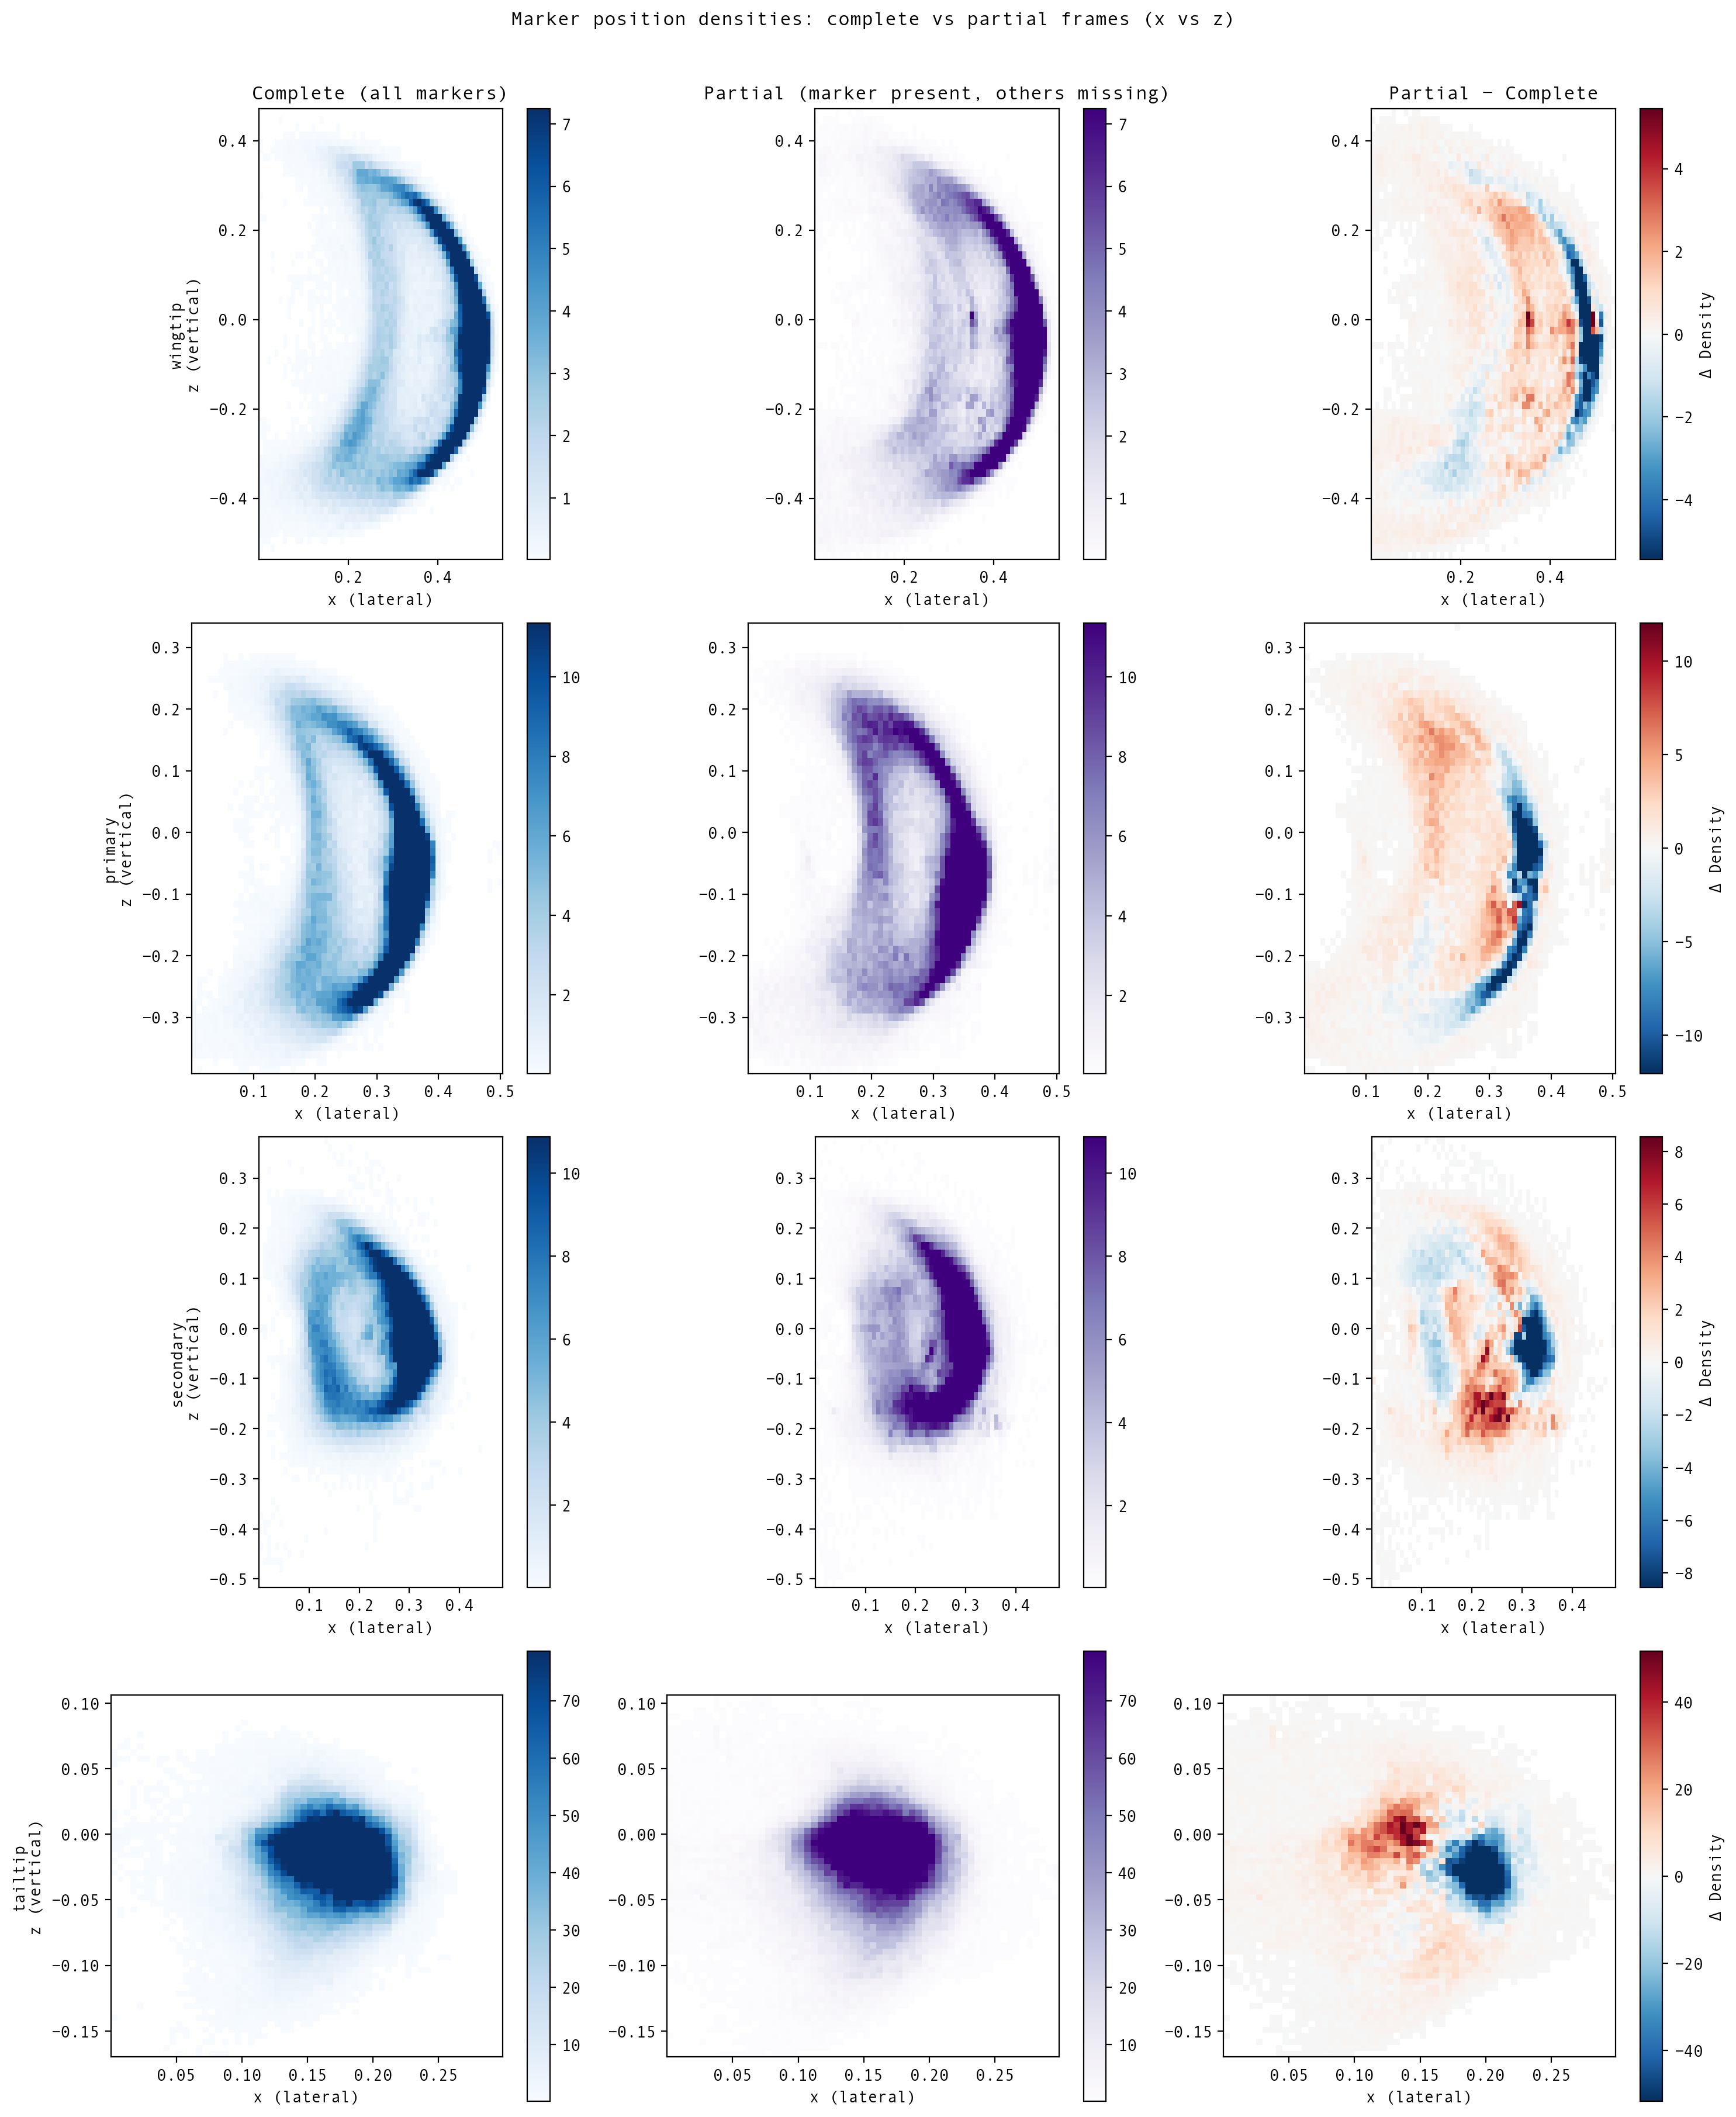

In [ ]:
# --- x vs z (lateral vs vertical) ---
fig_xz = plot_density_comparison(
    complete_data, partial_data, MARKER_NAMES,
    coord_a=0, coord_b=2,
    label_a='x (lateral)', label_b='z (vertical)',
    suptitle='Marker position densities: complete vs partial frames (x vs z)',
)
save_figure(fig_xz, str(FIGURE_DIR / 'S07_density_xz.pdf'))
plt.show()

Saved: ../../figures/supplementary/S06b_density_xy.pdf


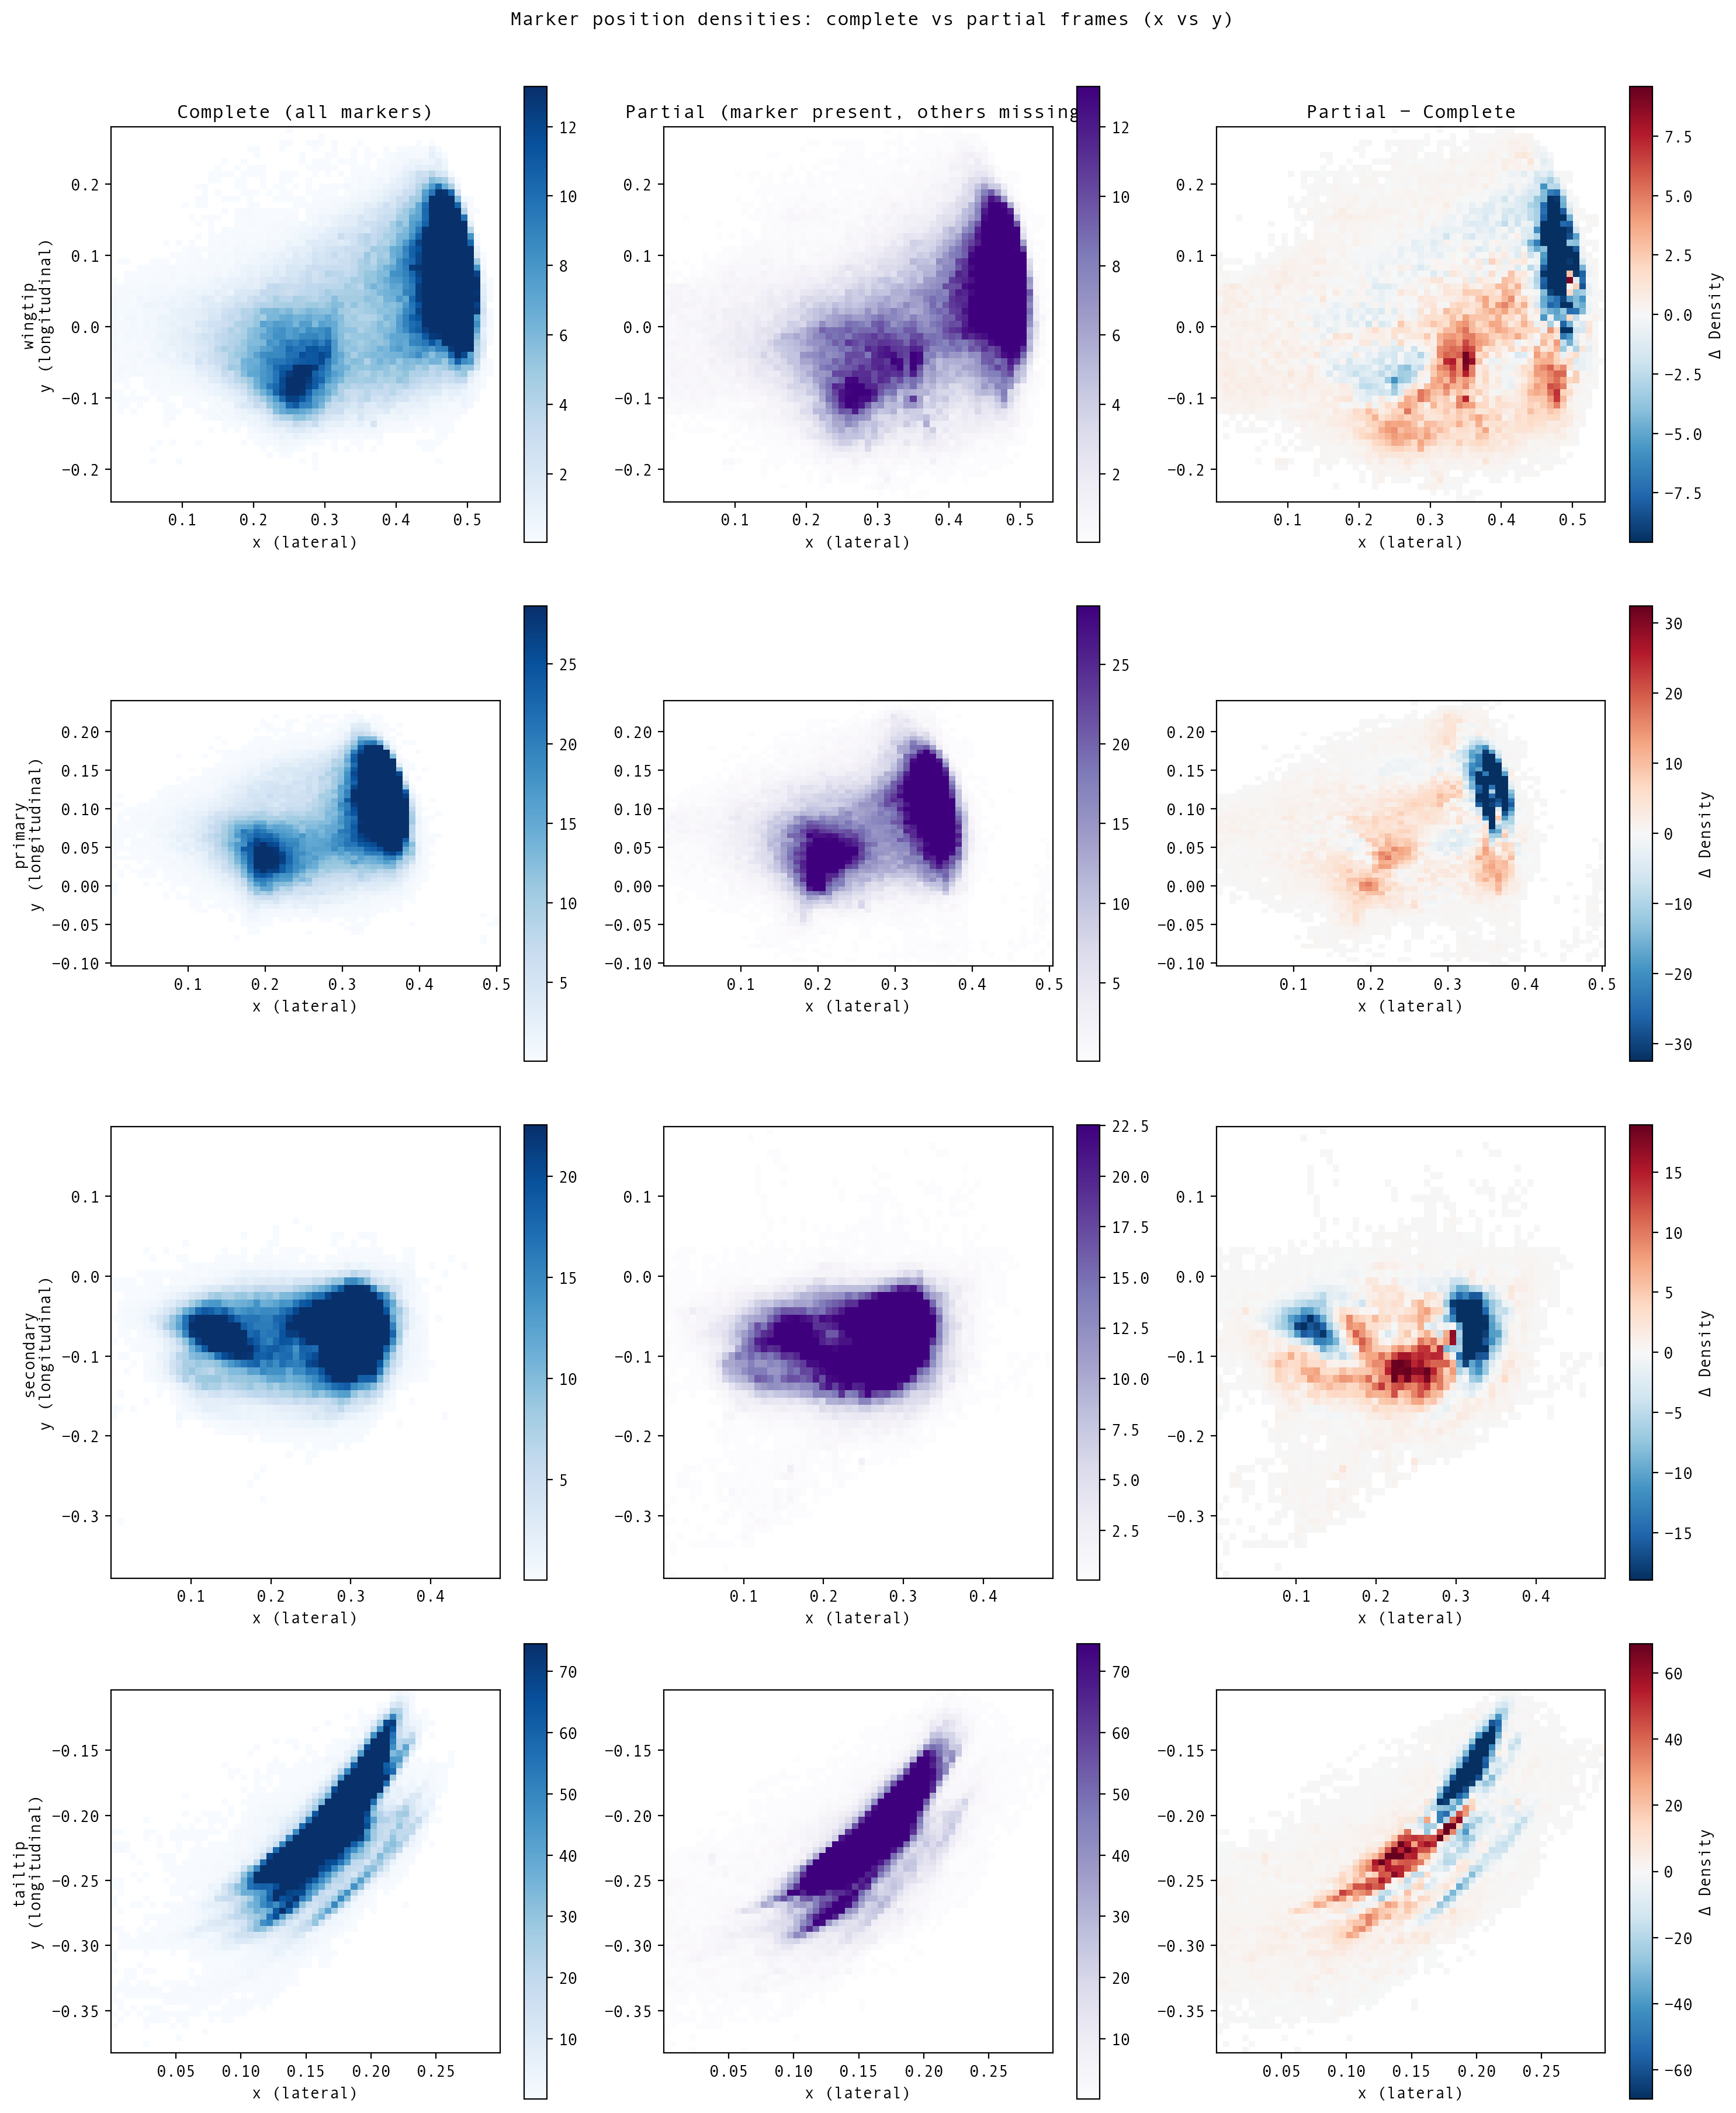

In [ ]:
# --- x vs y (lateral vs longitudinal) ---
fig_xy = plot_density_comparison(
    complete_data, partial_data, MARKER_NAMES,
    coord_a=0, coord_b=1,
    label_a='x (lateral)', label_b='y (longitudinal)',
    suptitle='Marker position densities: complete vs partial frames (x vs y)',
)
save_figure(fig_xy, str(FIGURE_DIR / 'S07_density_xy.pdf'))
plt.show()

Areas of red indicate where complete frames are denser, and areas of blue indicate where partial frames are denser. In the wingtip row at the very top, the difference panel shows that some labelled wingtip markers are actually primary markers, evidence of mislabelling. Both motion capture and the labelling pipeline is not perfect, however the previous notebook shows that the PCA results are robust to this noise. Overall the low density regions While there are differences in density, the overall structure of the kinematic morphospace is consistent between complete and partial frames, and the PCA results are robust to this sampling bias and missing data.

## Occlusion Robustness

The density comparison above shows *where* complete and partial frames differ spatially. We now test whether those differences matter for the PCA — do naturally occluded frames occupy a *different* morphing subspace, or the same one sampled differently?

Three tests follow:
1. **Occlusion-conditioned PCA** — compare PCA bases from complete vs naturally occluded frames.
2. **Projection validation** — verify that scoring partial frames via least-squares projection is accurate.
3. **Coverage comparison** — check whether partial frames visit regions of coordinate space that complete frames miss entirely.

In [ ]:
# --- Straight-flight complete dataset (for occlusion comparison) ---
straight_mask_complete = filter_by(frame_info, obstacle=0)
complete_unilateral = complete_markers[straight_mask_complete]
print(f"Complete straight-flight frames: {complete_unilateral.shape[0]:,}")

### Occlusion-Conditioned PCA

The previous dropout analysis shows *which* shapes are undersampled but not whether those frames occupy a *different* morphing space. To test this directly without imputation, we compare PCA bases computed from two groups of real marker positions:

- **Group A (complete, marker dropped):** All 126k complete straight-flight frames, with one marker removed -- the standard marker-subsetting test (NB06 §8.3).
- **Group B (naturally occluded):** Frames from the 559k dataset where that marker is genuinely missing but all others are present.

If occlusion is associated with a different region of morphing space, the PCA from Group B will differ from Group A. If the morphing structure is the same regardless of occlusion, the bases will align. This uses only real measured positions with no imputation or reconstruction.

Given the constraints of the motion capture recordings, we would expect the most folded configurations to have lower number of frames. It could be other configurations are also unrepresented. 

In [ ]:
# --- Compare PCA bases: complete frames vs naturally occluded frames ---
# For each marker, fit independent PCAs on:
#   Group A: complete frames with that marker artificially removed
#   Group B: frames where that marker is genuinely missing (others present)
marker_names = ["wingtip", "primary", "secondary", "tailtip"]

occlusion_rows = []
for drop_idx, drop_name in enumerate(marker_names):
    keep = [i for i in range(4) if i != drop_idx]

    # Group A: all complete unilateral frames, one marker dropped
    flat_complete = get_PCA_input(complete_unilateral[:, keep, :])
    flat_complete_centred = flat_complete - flat_complete.mean(axis=0)
    _, _, pca_complete = run_PCA(flat_complete_centred, flat_input=True, n_components=min(9, flat_complete.shape[1]))

    # Group B: 559k frames where target marker is missing, others present
    target_missing = np.isnan(partial_unilateral[:, drop_idx, 0])
    others_present = np.all(~np.isnan(partial_unilateral[:, keep, 0]), axis=1)
    occluded_mask = target_missing & others_present

    if occluded_mask.sum() < 100:
        occlusion_rows.append(dict(
            marker=drop_name, n_occluded=int(occluded_mask.sum()),
            cev_complete=0, cev_occluded=0, cosines=None,
        ))
        continue

    flat_occluded = get_PCA_input(partial_unilateral[occluded_mask][:, keep, :])
    flat_occluded_centred = flat_occluded - flat_occluded.mean(axis=0)
    _, _, pca_occluded = run_PCA(flat_occluded_centred, flat_input=True, n_components=min(9, flat_occluded.shape[1]))

    # Compare subspaces via principal cosines
    n_compare = min(4, pca_complete.n_components_, pca_occluded.n_components_)
    cosines = principal_cosines(
        pca_complete.components_[:n_compare].T,
        pca_occluded.components_[:n_compare].T,
        modes=n_compare,
    )
    cev_complete = np.cumsum(pca_complete.explained_variance_ratio_)[min(3, pca_complete.n_components_ - 1)]
    cev_occluded = np.cumsum(pca_occluded.explained_variance_ratio_)[min(3, pca_occluded.n_components_ - 1)]

    occlusion_rows.append(dict(
        marker=drop_name, n_occluded=int(occluded_mask.sum()),
        cev_complete=cev_complete, cev_occluded=cev_occluded,
        cosines=cosines,
    ))

print_occlusion_pca(occlusion_rows)


**Interpretation.** The dominant morphing modes (1–2) are virtually identical whether computed from complete frames or from frames where a marker is naturally occluded (cosines >0.99 in all cases). This confirms that marker occlusion does not select for a different region of morphing space -- the same low-dimensional structure governs wing-tail shape regardless of which markers happen to be visible.

Mode 3 shows greater divergence (cosines 0.73–0.96), particularly when the wingtip is occluded. This is expected: Mode 3 is a lower-variance component that is more sensitive to the loss of distal markers, and wingtip occlusion is the most shape-correlated dropout (above). Nevertheless, the subspace spanned by the first two modes (which together capture >90% of variance) is effectively invariant to natural occlusion patterns.

Together with the dropout analysis (above), these results show that the complete-marker subset undersamples folded-wing configurations by ~15 percentage points but that those configurations occupy the same morphing space as the rest of the data. The bias affects sampling density, not the morphing structure itself.

### Projection Validation

The occlusion bias test (below) relies on scoring partial frames via least-squares projection -- estimating PC1 and PC2 from whichever markers are visible. Before interpreting those results, we need to know how much error this introduces. If the projection is noisy enough to wash out real shifts, or biased enough to create false ones, the histogram comparison in the coverage comparison cannot be trusted.

We test this on the complete data where the true scores are known. For each frame, we mask one or two markers (simulating the real missing-data pattern), estimate PC1 and PC2 from the remaining markers, and compare against the true scores. The RMSE and correlation quantify the projection error.

In [ ]:
# Fit the full unilateral PCA (all 4 markers, matching the paper pipeline)
flat_unilateral = get_PCA_input(complete_unilateral)
mu_unilateral = flat_unilateral.mean(axis=0)
_, _, pca_unilateral = run_PCA(flat_unilateral - mu_unilateral, flat_input=True, n_components=4)
components = pca_unilateral.components_  # (4, 12)

# True scores with all 4 markers
true_scores = pca_unilateral.transform(flat_unilateral - mu_unilateral)
loadings = components[:2].T  # (12, 2) loadings for modes 1-2

marker_names = ["wingtip", "primary", "secondary", "tailtip"]

def _projection_row(label, observed_cols):
    loadings_obs = loadings[observed_cols, :]
    x_observed = flat_unilateral[:, observed_cols] - mu_unilateral[observed_cols]
    estimated = x_observed @ loadings_obs @ np.linalg.inv(loadings_obs.T @ loadings_obs)
    return dict(
        label=label,
        rmse_pc1=np.sqrt(np.mean((true_scores[:, 0] - estimated[:, 0])**2)),
        rmse_pc2=np.sqrt(np.mean((true_scores[:, 1] - estimated[:, 1])**2)),
        corr_pc1=np.corrcoef(true_scores[:, 0], estimated[:, 0])[0, 1],
        corr_pc2=np.corrcoef(true_scores[:, 1], estimated[:, 1])[0, 1],
    )

proj_rows = []

# One marker masked
for marker_idx, marker_name in enumerate(marker_names):
    observed = [c for c in range(12) if c // 3 != marker_idx]
    proj_rows.append(_projection_row(marker_name, observed))

proj_rows.append({"separator": True})

# Two markers masked
for (idx_a, name_a), (idx_b, name_b) in itertools.combinations(enumerate(marker_names), 2):
    observed = [c for c in range(12) if c // 3 != idx_a and c // 3 != idx_b]
    proj_rows.append(_projection_row(f"{name_a} + {name_b}", observed))

print_projection_validation(
    n_frames=flat_unilateral.shape[0],
    pc1_sd=true_scores[:, 0].std(),
    pc2_sd=true_scores[:, 1].std(),
    rows=proj_rows,
)


**Interpretation.** The projection is accurate: with one marker masked, correlations exceed 0.99 for both PC1 and PC2 across all markers. With two markers masked -- the worst case for the partial frames used in the coverage comparison -- the minimum correlation is 0.96 (wingtip + primary missing), with RMSE at ~23% of the score SD. The projection introduces noise but not systematic bias, so the distribution shifts observed in the coverage comparison reflect genuine differences in wing shape between complete and partial frames, not artefacts of the scoring method.

### Coverage: Do Partial Frames Visit New Regions?

Having established that the dominant morphing modes are shared regardless of marker occlusion (above), we now ask whether partial frames visit *new regions* of coordinate space that complete frames miss entirely. We bin each marker's raw positions (x vs z) and classify each bin as shared (both datasets), complete-only, or novel (partial-only). If partial frames merely resample the same region with different density, the novel fraction will be negligible.

In [ ]:
# --- Coverage comparison: do partial frames visit new regions? ---
marker_names = ['wingtip', 'primary', 'secondary', 'tailtip']
bins = 60

coverage_stats = []
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for m, (name, ax) in enumerate(zip(marker_names, axes)):
    xc = complete_data[:, m, 0]
    zc = complete_data[:, m, 2]

    present = ~np.isnan(partial_data[:, m, 0])
    xp = partial_data[present, m, 0]
    zp = partial_data[present, m, 2]

    x_range = (min(xc.min(), xp.min()), max(xc.max(), xp.max()))
    z_range = (min(zc.min(), zp.min()), max(zc.max(), zp.max()))
    hist_kw = dict(bins=bins, range=[x_range, z_range])

    H_c, xedges, zedges = np.histogram2d(xc, zc, **hist_kw)
    H_p, _, _ = np.histogram2d(xp, zp, **hist_kw)

    both = (H_c > 0) & (H_p > 0)
    complete_only = (H_c > 0) & (H_p == 0)
    novel = (H_c == 0) & (H_p > 0)

    # Softer palette
    rgb = np.ones((*H_c.T.shape, 4))
    rgb[both.T] = [0.75, 0.85, 0.93, 1.0]          # light steel blue
    rgb[complete_only.T] = [0.20, 0.50, 0.55, 1.0]  # muted teal
    rgb[novel.T] = [0.90, 0.40, 0.35, 1.0]          # coral

    ax.imshow(rgb, origin='lower',
              extent=[x_range[0], x_range[1], z_range[0], z_range[1]],
              aspect='equal')
    ax.set_xlabel('x (lateral)')
    if m == 0:
        ax.set_ylabel('z (vertical)')
    ax.set_title(name, fontweight='bold')

    n_shared = int(both.sum())
    n_complete_only = int(complete_only.sum())
    n_novel = int(novel.sum())
    n_occupied = n_shared + n_complete_only + n_novel
    frames_novel = H_p[novel].sum()
    frames_partial_total = H_p[H_p > 0].sum()
    coverage_stats.append({
        'Marker': name,
        'Shared': n_shared,
        'Complete only': n_complete_only,
        'Novel (partial)': n_novel,
        'Novel % bins': f'{n_novel / n_occupied:.1%}',
        'Frames in novel': f'{frames_novel:,.0f}',
        '% of partial': f'{frames_novel / frames_partial_total:.2%}',
    })

fig.legend(
    [Patch(facecolor=[0.75, 0.85, 0.93], edgecolor='0.5'),
     Patch(facecolor=[0.20, 0.50, 0.55], edgecolor='0.3'),
     Patch(facecolor=[0.90, 0.40, 0.35], edgecolor='0.3')],
    ['Both datasets', 'Complete only', 'Partial only (novel)'],
    loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02),
    frameon=False, fontsize=10,
)
fig.suptitle('Coverage comparison: do partial frames visit new regions?', y=1.01)
fig.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

# Summary table
print(pd.DataFrame(coverage_stats).to_string(index=False))

**Interpretation.** The coverage comparison confirms that partial frames do not visit meaningfully new regions of coordinate space. The vast majority of occupied bins are shared between complete and partial frames, with fewer than 1% of partial frames falling in novel bins.

The bias between complete and partial frames is therefore in *sampling density*, not in morphospace coverage. Complete frames overrepresent gliding and spread-wing configurations -- when all markers are most visible to overhead cameras -- while partial frames populate folded-wing and flapping-extreme regions more uniformly. 

## Missingness Patterns

We now explore the structure of missingness in detail: which markers drop out, how often, where the remaining markers are when one drops out, and whether marker labels are sometimes swapped.

### Dropout rates and co-occurrence

In [ ]:
# --- Per-marker dropout rates ---
print_marker_dropout_rates(MARKER_NAMES, partial_data)

Marker dropout rates in partial frames:
Marker          Missing    Present  Dropout %
---------------------------------------------
wingtip         241,844    311,052      43.7%
primary         309,223    243,673      55.9%
secondary       243,279    309,617      44.0%
tailtip         191,809    361,087      34.7%


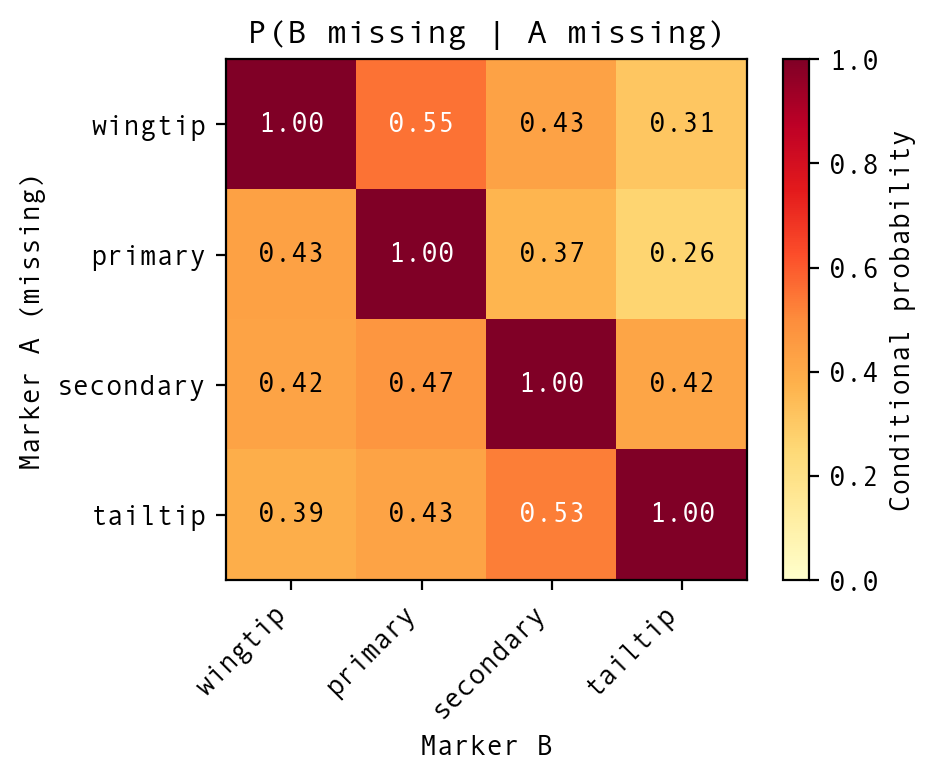

In [ ]:
# --- Co-occurrence of missingness ---
# When marker A is missing, how often is marker B also missing?
missing_mask = np.isnan(partial_data[:, :, 0])  # (N_partial, 4)

# Conditional probability: P(B missing | A missing)
co_occur = np.zeros((4, 4))
for a in range(4):
    a_missing = missing_mask[:, a]
    n_a = a_missing.sum()
    if n_a == 0:
        continue
    for b in range(4):
        co_occur[a, b] = (a_missing & missing_mask[:, b]).sum() / n_a

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(co_occur, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(MARKER_NAMES, rotation=45, ha='right')
ax.set_yticklabels(MARKER_NAMES)
ax.set_xlabel('Marker B')
ax.set_ylabel('Marker A (missing)')
ax.set_title('P(B missing | A missing)')

# Annotate cells
for a in range(4):
    for b in range(4):
        colour = 'white' if co_occur[a, b] > 0.5 else 'black'
        ax.text(b, a, f'{co_occur[a, b]:.2f}', ha='center', va='center',
                fontsize=10, color=colour)

plt.colorbar(im, ax=ax, label='Conditional probability')
fig.tight_layout()
plt.show()

In [ ]:
# --- Per-hawk dropout rates ---
# The unilateral data doubles frames (left + right), so use bilateral info
missing_straight_info = partial_info[straight_missing].copy()

# Per-marker missingness in bilateral data (check left side: indices 0,2,4,6)
bilateral_marker_names = ['wingtip', 'primary', 'secondary', 'tailtip']
bilateral_left_idx = [0, 2, 4, 6]

rows = []
for hawk_id, hawk_name in hawk_names.items():
    for year in [2017, 2020]:
        hmask = (missing_straight_info['BirdID'].astype(int).values == hawk_id) & \
                (missing_straight_info['Year'].astype(int).values == year)
        n_total = hmask.sum()
        if n_total == 0:
            continue
        subset = missing_straight[hmask]
        any_miss = np.any(np.isnan(subset), axis=(1, 2)).sum()
        row = {'Hawk': hawk_name, 'Year': year, 'Frames': n_total,
               'Partial %': any_miss / n_total}
        for m, (name, idx) in enumerate(zip(bilateral_marker_names, bilateral_left_idx)):
            # Check left side marker
            miss_count = np.isnan(subset[:, idx, 0]).sum()
            row[f'{name} %'] = miss_count / n_total
        rows.append(row)

dropout_df = pd.DataFrame(rows)
print(dropout_df.to_string(index=False, float_format='{:.1%}'.format))

      Hawk  Year  Frames  Partial %  wingtip %  primary %  secondary %  tailtip %
    Drogon  2017  104946      77.8%      25.6%      44.2%        35.2%      25.2%
    Drogon  2020   22640      78.8%      34.1%      41.0%        20.3%      21.7%
   Rhaegal  2017   97763      70.4%      27.9%      24.8%        32.1%      19.5%
      Ruby  2017   52249      79.2%      32.6%      22.2%        19.0%      27.9%
      Ruby  2020   32507      76.0%      27.6%      48.8%        13.6%      24.8%
 Toothless  2017  110443      63.9%      17.9%      40.1%        18.5%      15.1%
 Toothless  2020   25981      53.8%      23.0%      18.8%        18.1%      22.7%
Charmander  2020   21874      71.5%      19.2%       9.5%        38.0%      10.1%


### Where are the other markers when one drops out?

For each target marker that is missing, we plot the positions of the *remaining* markers that are still visible. This reveals whether dropout is posture-dependent — e.g. the wingtip disappears when wings are folded.

In [ ]:
def plot_dropout_positions(complete_data, partial_data, marker_names,
                           coord_a, coord_b, label_a, label_b,
                           suptitle, bins=60):
    """For each target marker that is missing, plot positions of the other markers."""
    fig, axes = plt.subplots(len(marker_names), 3,
                             figsize=(15, 4.5 * len(marker_names)))

    for m_target, target_name in enumerate(marker_names):
        others = [i for i in range(len(marker_names)) if i != m_target]

        # Complete frames: target present, extract other markers
        ac = complete_data[:, others, coord_a].ravel()
        bc = complete_data[:, others, coord_b].ravel()

        # Partial frames where target is MISSING but others are present
        target_missing = np.isnan(partial_data[:, m_target, 0])
        others_present = np.all(~np.isnan(partial_data[:, others, 0]), axis=1)
        dropout_mask = target_missing & others_present

        ap = partial_data[dropout_mask][:, others, coord_a].ravel()
        bp = partial_data[dropout_mask][:, others, coord_b].ravel()

        n_dropout = dropout_mask.sum()
        print(f'{target_name} missing (others present): {n_dropout:,} frames')

        if n_dropout < 100:
            for ax in axes[m_target, :]:
                ax.text(0.5, 0.5, 'Too few frames', transform=ax.transAxes, ha='center')
            continue

        # Shared range
        a_range = (min(ac.min(), ap.min()), max(ac.max(), ap.max()))
        b_range = (min(bc.min(), bp.min()), max(bc.max(), bp.max()))
        hist_kw = dict(bins=bins, range=[a_range, b_range], density=True)

        H_c, aedges, bedges = np.histogram2d(ac, bc, **hist_kw)
        H_p, _, _ = np.histogram2d(ap, bp, **hist_kw)

        vmax = np.nanquantile(np.concatenate([H_c.ravel(), H_p.ravel()]), 0.95)

        # Complete
        H_plot = H_c.T.copy()
        H_plot[H_plot == 0] = np.nan
        im = axes[m_target, 0].pcolormesh(aedges, bedges, H_plot, cmap='Blues', vmax=vmax)
        axes[m_target, 0].set_ylabel(f'{target_name} missing\n{label_b}')
        if m_target == 0:
            axes[m_target, 0].set_title('Other markers (complete)')
        plt.colorbar(im, ax=axes[m_target, 0])

        # Dropout frames
        H_plot = H_p.T.copy()
        H_plot[H_plot == 0] = np.nan
        im = axes[m_target, 1].pcolormesh(aedges, bedges, H_plot, cmap='Purples', vmax=vmax)
        if m_target == 0:
            axes[m_target, 1].set_title('Other markers (dropout)')
        plt.colorbar(im, ax=axes[m_target, 1])

        # Difference
        H_diff = H_p.T - H_c.T
        mask = (H_c.T > 0) | (H_p.T > 0)
        H_diff[~mask] = np.nan
        vabs = np.nanquantile(np.abs(H_diff), 0.98)
        im = axes[m_target, 2].pcolormesh(aedges, bedges, H_diff, cmap='RdBu_r',
                                          vmin=-vabs, vmax=vabs)
        if m_target == 0:
            axes[m_target, 2].set_title('Dropout \u2212 Complete')
        plt.colorbar(im, ax=axes[m_target, 2], label='\u0394 Density')

        for ax in axes[m_target, :]:
            ax.set_xlabel(label_a)
            ax.set_aspect('equal')

    fig.suptitle(suptitle, y=1.01)
    fig.tight_layout()
    return fig

wingtip missing (others present): 57,861 frames
primary missing (others present): 105,957 frames
secondary missing (others present): 60,376 frames
tailtip missing (others present): 44,817 frames
Saved: ../../figures/supplementary/S06b_dropout_positions_xz.pdf


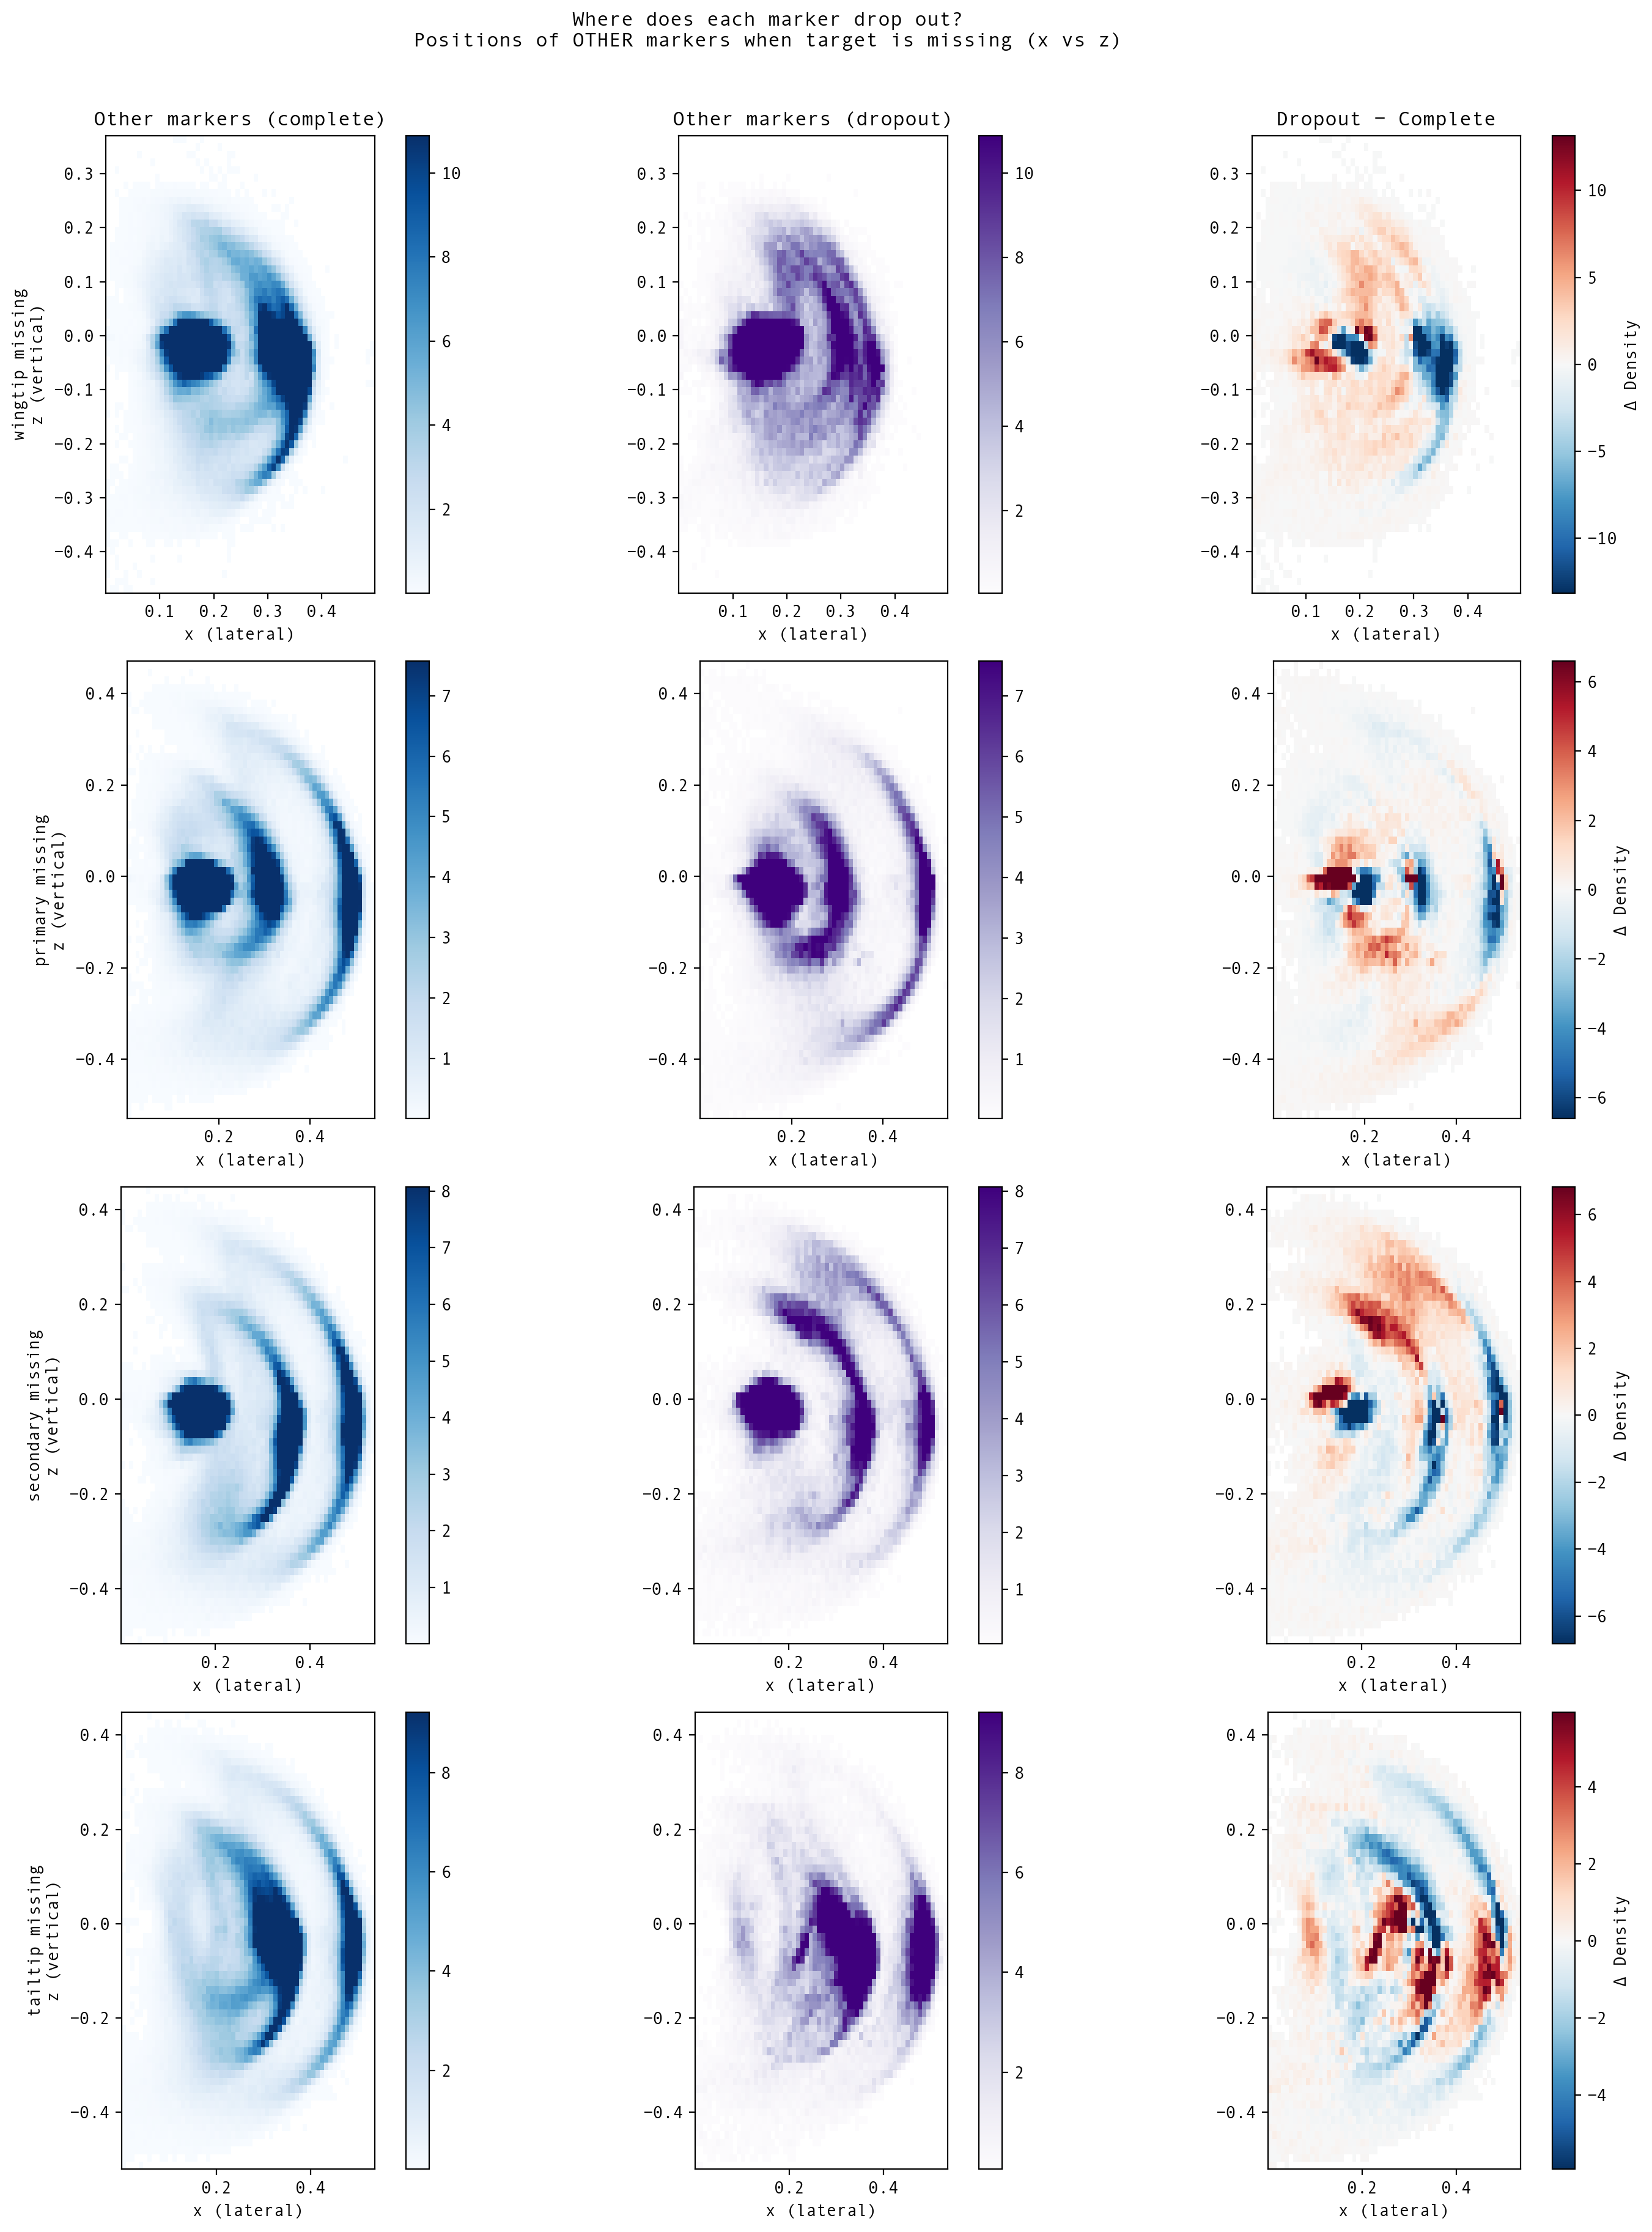

In [ ]:
# --- Dropout positions: x vs z ---
fig_drop_xz = plot_dropout_positions(
    complete_data, partial_data, MARKER_NAMES,
    coord_a=0, coord_b=2,
    label_a='x (lateral)', label_b='z (vertical)',
    suptitle='Where does each marker drop out?\nPositions of OTHER markers when target is missing (x vs z)',
)
save_figure(fig_drop_xz, str(FIGURE_DIR / 'S07_dropout_positions_xz.pdf'))
plt.show()

wingtip missing (others present): 57,861 frames
primary missing (others present): 105,957 frames
secondary missing (others present): 60,376 frames
tailtip missing (others present): 44,817 frames
Saved: ../../figures/supplementary/S06b_dropout_positions_xy.pdf


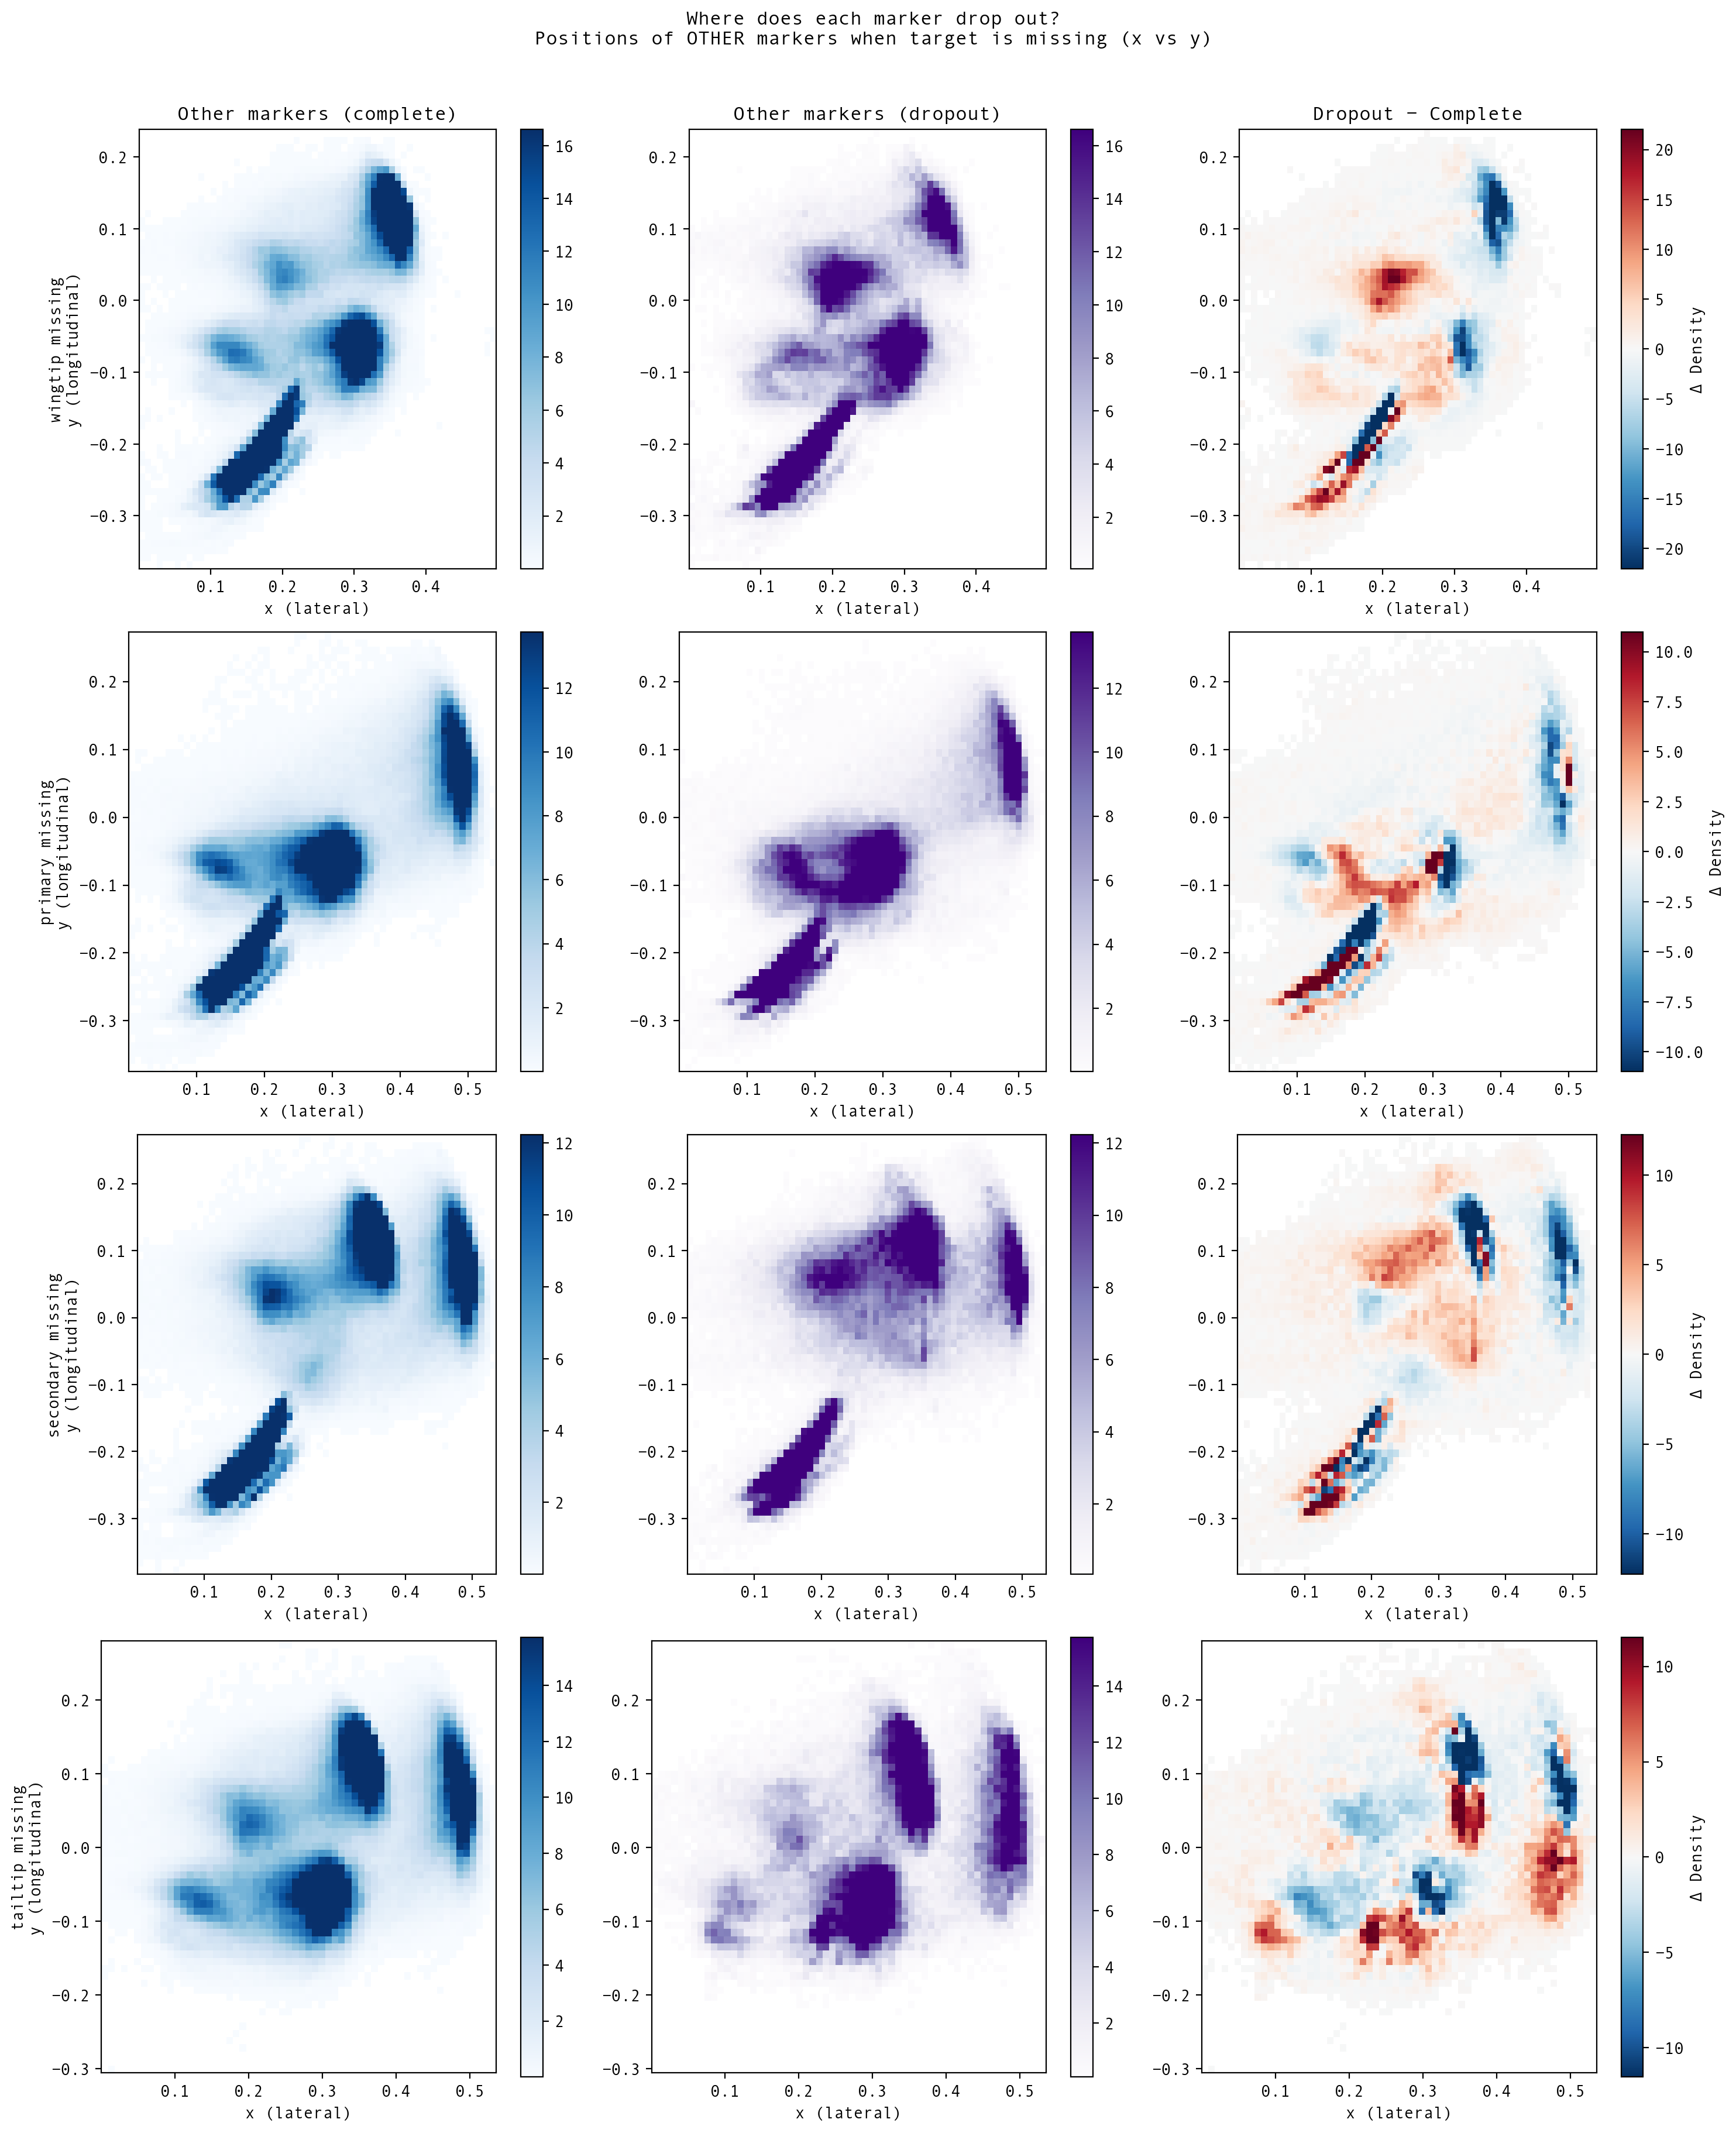

In [ ]:
# --- Dropout positions: x vs y ---
fig_drop_xy = plot_dropout_positions(
    complete_data, partial_data, MARKER_NAMES,
    coord_a=0, coord_b=1,
    label_a='x (lateral)', label_b='y (longitudinal)',
    suptitle='Where does each marker drop out?\nPositions of OTHER markers when target is missing (x vs y)',
)
save_figure(fig_drop_xy, str(FIGURE_DIR / 'S07_dropout_positions_xy.pdf'))
plt.show()

**Interpretation.** Marker dropout is posture-dependent, not random. When the wingtip is missing, the remaining markers show the wing in a more folded configuration — distal feather markers tuck behind the body during deep wingbeats. When the tailtip is missing, the remaining wing markers show more extreme tail deflections. This confirms that certain wing configurations preferentially lose markers, and the complete-marker subset undersamples these extreme postures.

### Mislabelling detection

Motion-capture reconstruction software can confuse nearby markers during rapid movement, swapping their labels. Along the wing, the anatomical ordering should always be: **secondary** (most proximal) < **primary** < **wingtip** (most distal) in the lateral (x) direction. Violations of this ordering indicate label swaps.

We test this on frames where the relevant markers are both present.

In [ ]:
# --- Anatomical ordering violations ---
# Expected x-ordering (lateral): secondary < primary < wingtip
# Marker indices: 0=wingtip, 1=primary, 2=secondary, 3=tailtip

# Test on all unilateral frames (complete + partial) where the relevant pair is present
all_data = partial_unilateral

pairs = [
    ('secondary', 'primary', 2, 1),   # secondary.x should be < primary.x
    ('primary', 'wingtip', 1, 0),      # primary.x should be < wingtip.x
    ('secondary', 'wingtip', 2, 0),    # secondary.x should be < wingtip.x
]

violation_masks = print_anatomical_violations(all_data, pairs)

Pair                        Testable   Violations     Rate
----------------------------------------------------------
secondary >= primary         497,601       63,074   12.68%
primary >= wingtip           519,699       17,092    3.29%
secondary >= wingtip         554,675        7,375    1.33%


In [ ]:
# --- Break down violations by complete vs partial frames ---
print_violation_breakdown(violation_masks, any_nan)

Pair                          Complete      Partial
----------------------------------------------------
secondary_vs_primary      33,452 (8.71%) 29,622 (5.36%)
primary_vs_wingtip        10,131 (2.64%)  6,961 (1.26%)
secondary_vs_wingtip       3,697 (0.96%)  3,678 (0.67%)


Saved: ../../figures/supplementary/S06b_ordering_violations.pdf


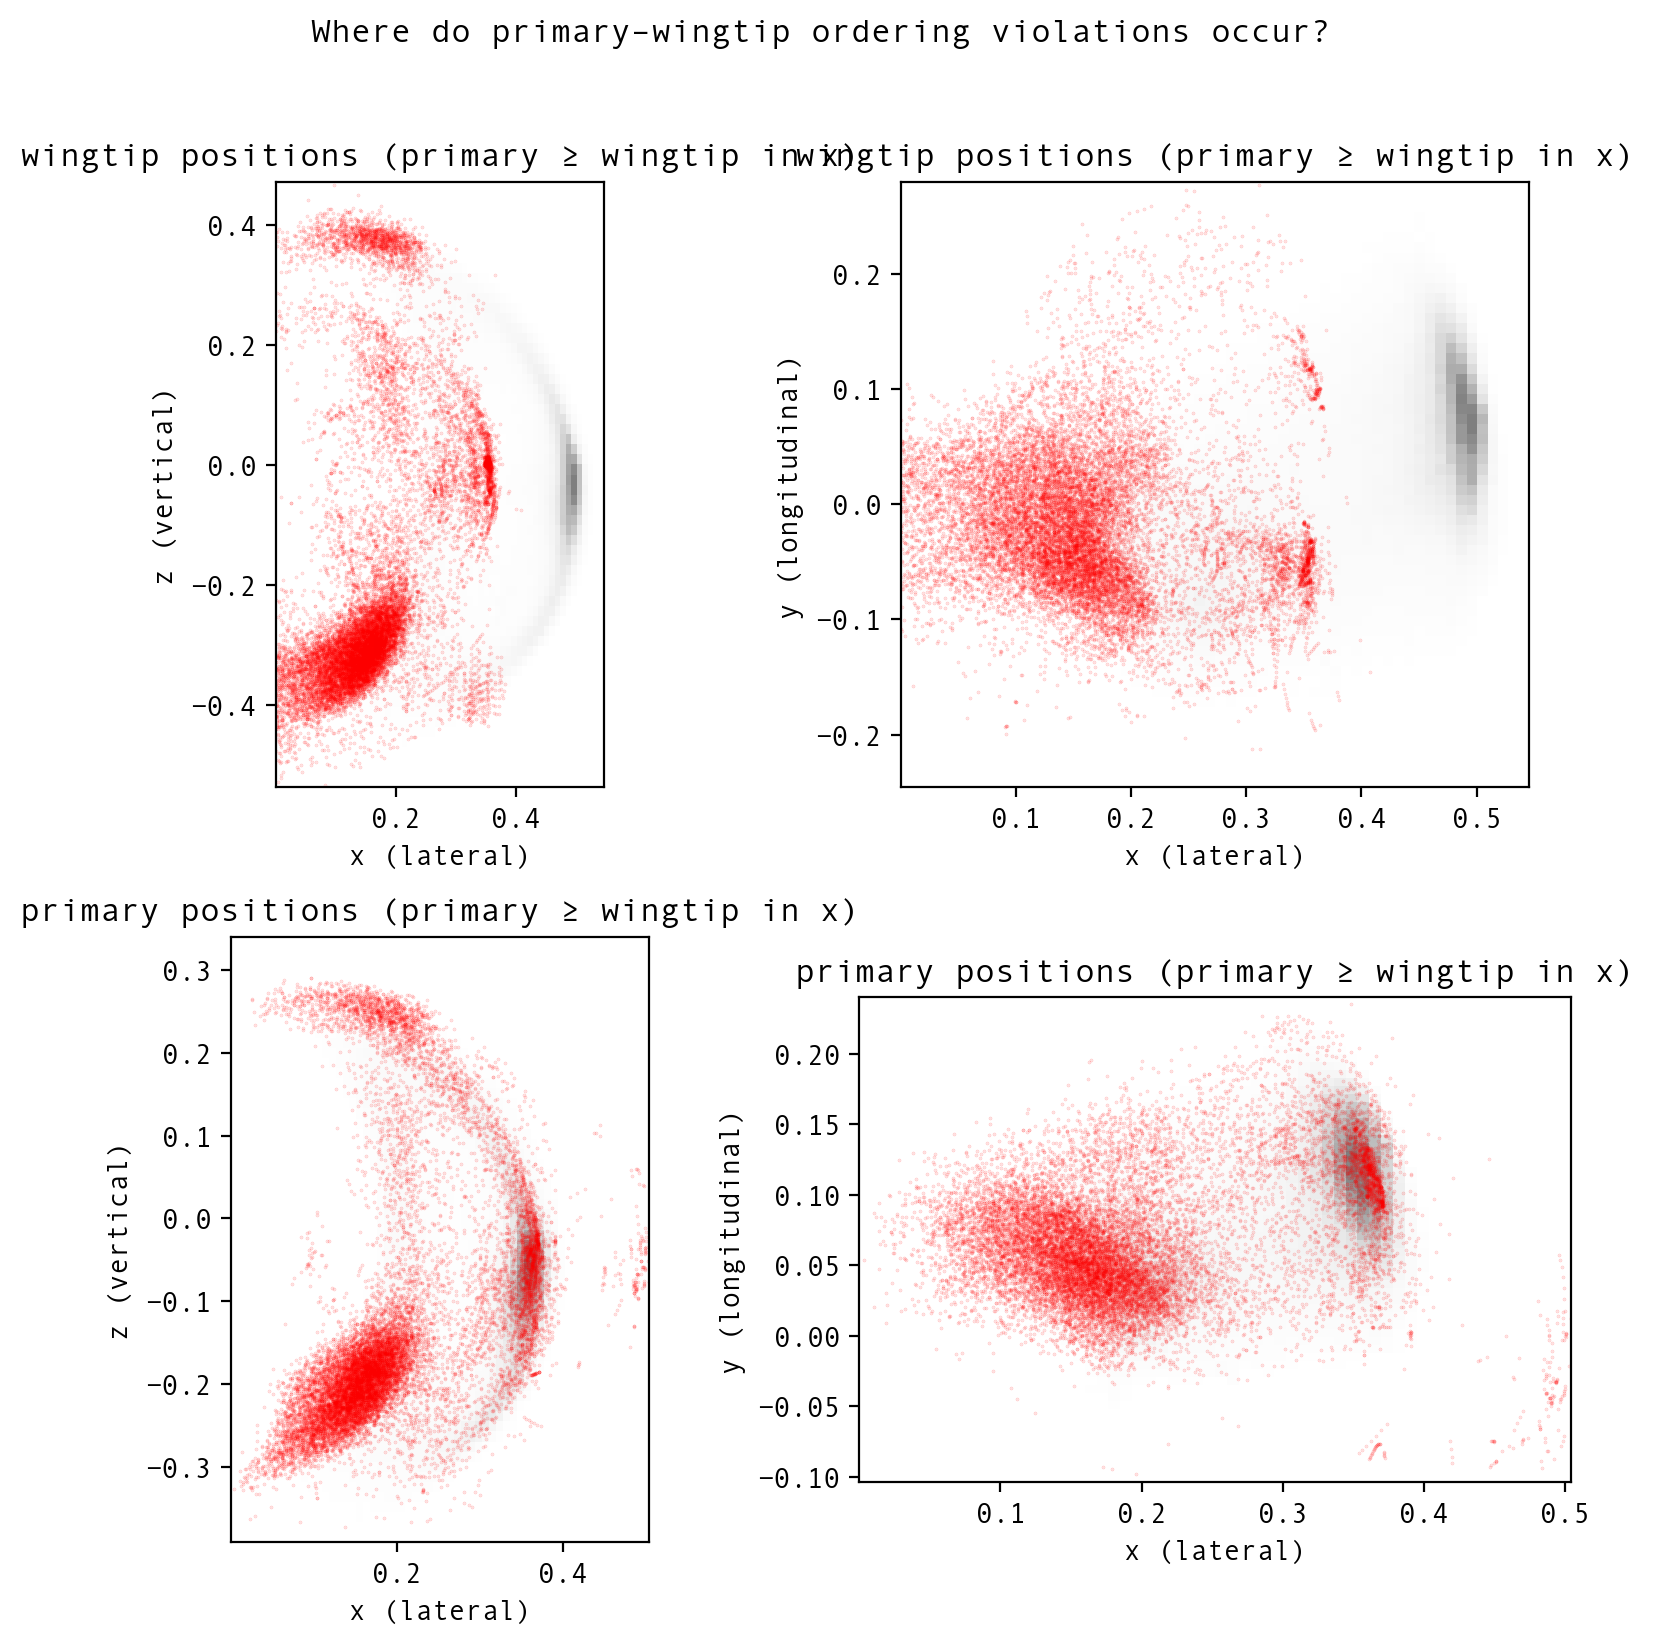

In [ ]:
# --- Spatial evidence: where do ordering violations occur? ---
# Overlay violation frames on the density plots for the most common swap pair
# (primary vs wingtip, indices 1 and 0)

viol_mask = violation_masks['primary_vs_wingtip']
viol_frames = all_data[viol_mask]

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for col, (coord_a, coord_b, lab_a, lab_b) in enumerate([
    (0, 2, 'x (lateral)', 'z (vertical)'),
    (0, 1, 'x (lateral)', 'y (longitudinal)'),
]):
    for row, (m, name) in enumerate([(0, 'wingtip'), (1, 'primary')]):
        ax = axes[row, col]

        # Background: all frames density
        present = ~np.isnan(all_data[:, m, 0])
        a_all = all_data[present, m, coord_a]
        b_all = all_data[present, m, coord_b]

        ax.hist2d(a_all, b_all, bins=60, cmap='Greys', alpha=0.5,
                  density=True)

        # Overlay: violation frames
        viol_present = viol_mask & present
        a_viol = all_data[viol_present, m, coord_a]
        b_viol = all_data[viol_present, m, coord_b]

        ax.scatter(a_viol, b_viol, c='red', s=0.1, alpha=0.2, rasterized=True)
        ax.set_xlabel(lab_a)
        ax.set_ylabel(lab_b)
        ax.set_title(f'{name} positions (primary \u2265 wingtip in x)')
        ax.set_aspect('equal')

fig.suptitle('Where do primary\u2013wingtip ordering violations occur?', y=1.02)
fig.tight_layout()
save_figure(fig, str(FIGURE_DIR / 'S07_ordering_violations.pdf'))
plt.show()

**Interpretation.** Ordering violations — frames where the primary marker appears more lateral than the wingtip — cluster in specific regions of coordinate space. These correspond to the red excess regions visible in the §2 density difference plots, confirming that the density mismatch between complete and partial frames is partly driven by mislabelled markers.

The mislabelling rate quantifies how often the reconstruction software confuses adjacent feather markers during rapid wing movement. Notably, violation rates are slightly higher in complete frames than in partial frames — this likely reflects the labelling pipeline: when fewer markers are visible, the software has fewer candidates to confuse, so label swaps are less common. In the complete 8-marker dataset used for PCA, these ordering violations are present at a low rate and concentrated in extreme wing configurations where adjacent markers are physically closest.

## Summary & Limitations

| Test | Question | Finding |
|------|----------|---------|
| **Flight-phase CEV** | Does sampling bias inflate variance concentration? | CEV₄ is highest in flapping phases (~97%) and lowest in glide + landing (~91%); the combined 96.3% is pulled down by phase 4, not inflated |
| **Density comparison** | Do complete and partial frames occupy the same coordinate space? | Complete frames overrepresent gliding configurations by 8–13 pp; partial frames populate folded-wing regions more uniformly |
| **Occlusion-conditioned PCA** | Do naturally occluded frames have a different morphing subspace? | Modes 1–2 cosines > 0.99 for all markers; same subspace regardless of occlusion |
| **Projection validation** | Can we trust PC scores estimated from partial markers? | Correlations > 0.99 (1 marker masked), > 0.96 (2 markers masked); no systematic bias |
| **Coverage comparison** | Do partial frames visit new regions that complete frames miss? | < 1% of partial frames fall in novel bins; bias is in density, not coverage |
| **Dropout rates** | Which markers disappear and how often? | Distal markers (wingtip, primary) drop most; co-dropout reflects shared postural cause |
| **Mislabelling detection** | Are marker labels sometimes swapped? | Anatomical ordering violations cluster at rapid-movement configurations; wingtip–primary swaps most common |

**Key conclusion:** The complete-marker dataset undersamples folded-wing and flapping-extreme configurations, but the morphospace structure is identical regardless of marker visibility. The bias affects sampling density, not the PCA results.

**Limitations not addressed here:**

- **Ghost markers** — spurious reflections that create phantom marker detections — are a known motion-capture artefact but are not formally tested in this analysis.
- **Temporal structure of dropout** — whether markers tend to disappear for long stretches or flicker on and off is not explored here (see NB06 §8.6 for temporal autocorrelation of the complete dataset).